Team Ranking Intelligence Platform

FIFA World Cup — Cross-Tournament Team Rankings & Performance Analytics

Dataset: FIFA World Cup Matches (1930–2014)

Goal: Rank teams across tournaments using multi-dimensional scoring

Metrics: Wins, Goals, Win Rate, Points, Consistency, Goal Difference

✅ Libraries loaded successfully!
📤 Please upload your WorldCupMatches.csv file:


Saving WorldCupMatches (1).csv to WorldCupMatches (1) (1).csv

✅ File loaded: WorldCupMatches (1) (1).csv
   Shape : 4,572 rows × 20 columns
   Columns: ['Year', 'Datetime', 'Stage', 'Stadium', 'City', 'Home Team Name', 'Home Team Goals', 'Away Team Goals', 'Away Team Name', 'Win conditions', 'Attendance', 'Half-time Home Goals', 'Half-time Away Goals', 'Referee', 'Assistant 1', 'Assistant 2', 'RoundID', 'MatchID', 'Home Team Initials', 'Away Team Initials']
✅ Cleaned dataset: 852 valid matches
   Tournaments: [np.int64(1930), np.int64(1934), np.int64(1938), np.int64(1950), np.int64(1954), np.int64(1958), np.int64(1962), np.int64(1966), np.int64(1970), np.int64(1974), np.int64(1978), np.int64(1982), np.int64(1986), np.int64(1990), np.int64(1994), np.int64(1998), np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014)]
   Year              Datetime    Stage         Stadium         City  \
0  1930  13 Jul 1930 - 15:00   Group 1         Pocitos  Montevideo    
1  1930  13 Jul 1930 

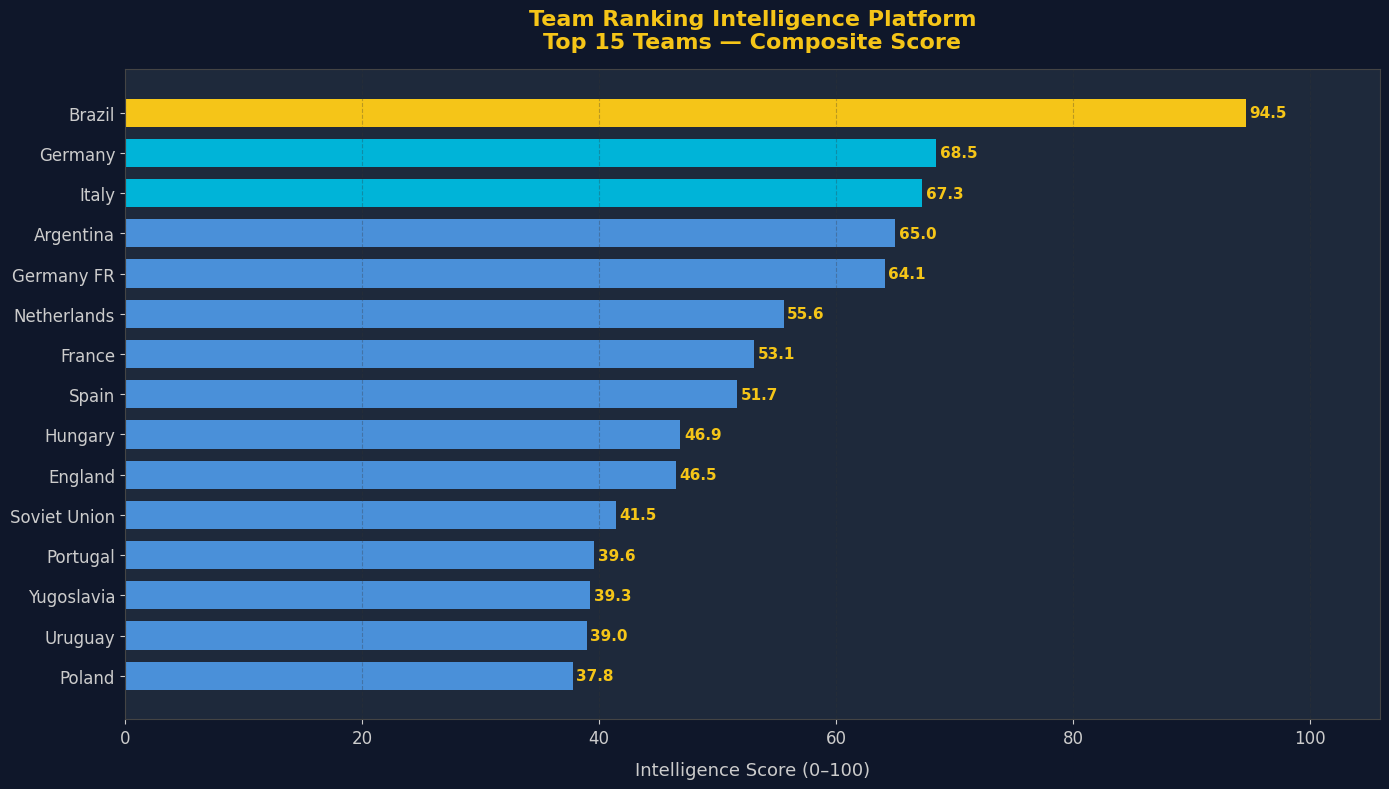

Chart saved as top15_intelligence_score.png


📅 TOP 5 TEAMS PER TOURNAMENT

  🗓️  1930
 Tournament_Rank       Team  MP  W  D  L  Pts  GD
               1    Uruguay   4  4  0  0   12  12
               2  Argentina   5  4  0  1   12   9
               3      Chile   3  2  0  1    6   2
               4        USA   3  2  0  1    6   1
               5 Yugoslavia   3  2  0  1    6   0

  🗓️  1934
 Tournament_Rank           Team  MP  W  D  L  Pts  GD
               1          Italy   5  4  1  0   13   9
               2        Germany   4  3  0  1    9   3
               3 Czechoslovakia   4  3  0  1    9   3
               4        Austria   4  2  0  2    6   0
               5          Spain   3  1  1  1    4   1

  🗓️  1938
 Tournament_Rank           Team  MP  W  D  L  Pts  GD
               1          Italy   4  4  0  0   12   6
               2         Brazil   5  3  1  1   10   3
               3        Hungary   4  3  0  1    9  10
               4 Czechoslovakia   3  1  1  1    4   2
               5    Switzerland   3  1  1

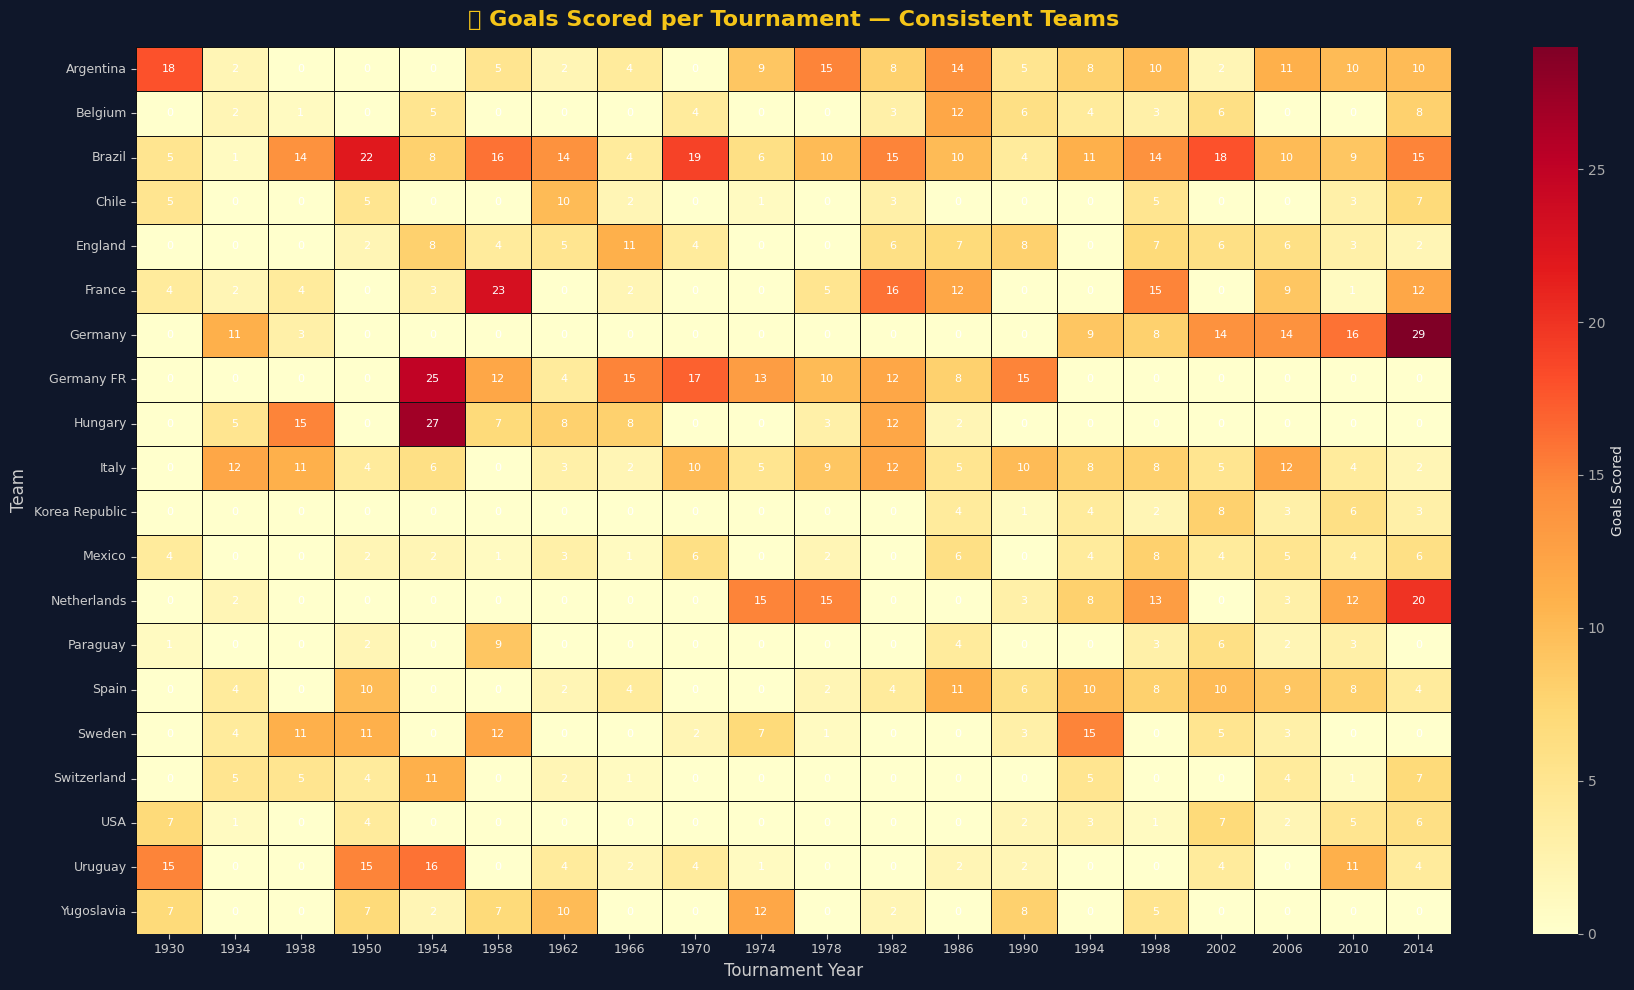

✅ Heatmap saved as heatmap_goals.png


Enter team name (e.g. Brazil, Germany): germany

🔍 TEAM PROFILE: Germany
  Global Rank         : #2
  Intelligence Score  : 68.45
  Tournaments Played  : 8
  Total Matches       : 48
  Wins / Draws / Loss : 34 / 6 / 8
  Win Rate            : 70.83%
  Goals For / Against : 104 / 46
  Goal Difference     : +58
  Total Points        : 108
  Points Per Game     : 2.25
  Goals Per Game      : 2.17
✅ Rankings exported → team_ranking_intelligence_platform.csv
   Total teams ranked: 47
    Rank          Team  Tournaments  Matches_Played  Wins  Draws  Losses  \
0      1        Brazil           20             108    71     18      19   
1      2       Germany            8              48    34      6       8   
2      3         Italy           18              83    45     21      17   
3      4     Argentina           16              81    44     15      22   
4      5    Germany FR           10              62    36     14      12   
5      6   Netherlands           10              54    29    

In [3]:
# step1-Install required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ── Styling ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#e0e0e0',
    'grid.color':       '#333',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
})

ACCENT   = '#f5c518'   # gold
ACCENT2  = '#00b4d8'  # cyan
ACCENT3  = '#e94560'  # red
BG_DARK  = '#0f0f1a'
BG_MID   = '#1a1a2e'

print('✅ Libraries loaded successfully!')

#step2-Upload & Load Dataset

from google.colab import files

print('📤 Please upload your WorldCupMatches.csv file:')
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]))
df = df_raw.copy() # Assign df_raw to df

print(f'\n✅ File loaded: {filename}')
print(f'   Shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'   Columns: {list(df_raw.columns)}')

# ── Drop missing values ─────────────────────────
df.dropna(subset=[
    'Home Team Initials',
    'Away Team Initials',
    'Home Team Goals',
    'Away Team Goals',
    'Year'
], inplace=True)

#step3 — Data Cleaning & Preprocessing

# ── Convert types ───────────────────────────────
df['Year'] = df['Year'].astype(int)
df['Home Team Goals'] = df['Home Team Goals'].astype(int)
df['Away Team Goals'] = df['Away Team Goals'].astype(int)

# ── Clean text ──────────────────────────────────
df['Home Team Initials'] = df['Home Team Initials'].str.strip()
df['Away Team Initials'] = df['Away Team Initials'].str.strip()

# ── Match results ───────────────────────────────
df['Home Win'] = (df['Home Team Goals'] > df['Away Team Goals']).astype(int)
df['Away Win'] = (df['Away Team Goals'] > df['Home Team Goals']).astype(int)
df['Draw'] = (df['Home Team Goals'] == df['Away Team Goals']).astype(int)

# ── Output ──────────────────────────────────────
print(f'✅ Cleaned dataset: {len(df):,} valid matches')
print(f'   Tournaments: {sorted(df["Year"].unique())}')

print(df.head(3))

#step4— Build the Team Statistics Engine

def compute_team_stats(dataframe):
    """
    Given a matches dataframe, compute per-team aggregated stats
    across all matches (home + away combined).
    """
    records = []

    for _, row in dataframe.iterrows():
        ht, at = row['Home Team Name'], row['Away Team Name']
        hg, ag = row['Home Team Goals'], row['Away Team Goals']
        yr     = row['Year']

        # Home team perspective
        records.append({
            'Team': ht, 'Year': yr,
            'GF': hg, 'GA': ag,
            'Win': 1 if hg > ag else 0,
            'Draw': 1 if hg == ag else 0,
            'Loss': 1 if hg < ag else 0,
        })
        # Away team perspective
        records.append({
            'Team': at, 'Year': yr,
            'GF': ag, 'GA': hg,
            'Win': 1 if ag > hg else 0,
            'Draw': 1 if hg == ag else 0,
            'Loss': 1 if ag < hg else 0,
        })

    match_df = pd.DataFrame(records)

    stats = match_df.groupby('Team').agg(
        Tournaments     = ('Year', 'nunique'),
        Matches_Played  = ('Win', 'count'),
        Wins            = ('Win', 'sum'),
        Draws           = ('Draw', 'sum'),
        Losses          = ('Loss', 'sum'),
        Goals_For       = ('GF', 'sum'),
        Goals_Against   = ('GA', 'sum'),
    ).reset_index()

    stats['Goal_Difference'] = stats['Goals_For'] - stats['Goals_Against']
    stats['Points']          = stats['Wins'] * 3 + stats['Draws'] * 1
    stats['Win_Rate']        = (stats['Wins'] / stats['Matches_Played'] * 100).round(2)
    stats['Goals_Per_Game']  = (stats['Goals_For'] / stats['Matches_Played']).round(2)
    stats['Points_Per_Game'] = (stats['Points'] / stats['Matches_Played']).round(2)

    return stats, match_df

team_stats, match_records = compute_team_stats(df)

print(f'✅ Statistics computed for {len(team_stats)} unique teams')
team_stats.sort_values('Points', ascending=False).head(10)

#step5— Composite Ranking Score (Intelligence Score)

from sklearn.preprocessing import MinMaxScaler

# ── Minimum match threshold to filter one-off teams ───────────────────────
MIN_MATCHES = 10
ranked = team_stats[team_stats['Matches_Played'] >= MIN_MATCHES].copy()

# ── Metrics to include in composite score ────────────────────────────────
score_cols = ['Points', 'Win_Rate', 'Goal_Difference',
              'Goals_Per_Game', 'Tournaments', 'Points_Per_Game']

weights = {
    'Points':          0.30,
    'Win_Rate':        0.25,
    'Goal_Difference': 0.20,
    'Goals_Per_Game':  0.10,
    'Tournaments':     0.08,
    'Points_Per_Game': 0.07,
}

scaler = MinMaxScaler()
ranked[score_cols] = ranked[score_cols].fillna(0)
scaled = scaler.fit_transform(ranked[score_cols])
scaled_df = pd.DataFrame(scaled, columns=score_cols, index=ranked.index)

ranked['Intelligence_Score'] = sum(
    scaled_df[col] * w for col, w in weights.items()
) * 100
ranked['Intelligence_Score'] = ranked['Intelligence_Score'].round(2)

ranked = ranked.sort_values('Intelligence_Score', ascending=False).reset_index(drop=True)
ranked.index += 1  # rank starts at 1
ranked.index.name = 'Rank'

print('🏆 TOP 20 TEAMS — INTELLIGENCE SCORE RANKING')
print('=' * 65)
print(ranked[['Team','Tournaments','Matches_Played','Wins','Draws',
                'Losses','Points','Win_Rate','Goal_Difference',
                'Intelligence_Score']].head(20))

#step6— Visualization: Top 15 Teams by Intelligence Score

top15 = ranked.head(15)
BG_DARK = "#0f172a"
BG_MID = "#1e293b"
#BG_LIGHT = "#334155"
ACCENT   = '#f5c518'   # gold
ACCENT2  = '#00b4d8'

fig, ax = plt.subplots(figsize=(14, 8), facecolor=BG_DARK)
ax.set_facecolor(BG_MID)

colors = [ACCENT if i == 0 else ACCENT2 if i < 3 else '#4a90d9'
          for i in range(len(top15))]

bars = ax.barh(top15['Team'][::-1], top15['Intelligence_Score'][::-1],
               color=colors[::-1], edgecolor='none', height=0.7)

for bar, score in zip(bars, top15['Intelligence_Score'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}', va='center', ha='left',
            color=ACCENT, fontsize=11, fontweight='bold')

ax.set_xlabel('Intelligence Score (0–100)', fontsize=13, color='#ccc', labelpad=10)
ax.set_title('Team Ranking Intelligence Platform\nTop 15 Teams — Composite Score',
             fontsize=16, color=ACCENT, fontweight='bold', pad=15)
ax.set_xlim(0, top15['Intelligence_Score'].max() * 1.12)
ax.grid(axis='x', alpha=0.3)
ax.tick_params(colors='#ccc', labelsize=12)
plt.tight_layout()
plt.savefig('top15_intelligence_score.png', dpi=150, bbox_inches='tight',
            facecolor=BG_DARK)
plt.show()
print('Chart saved as top15_intelligence_score.png')

#step7— Interactive Scatter: Win Rate vs Goal Difference


fig = px.scatter(
    ranked.reset_index(),
    x='Win_Rate',
    y='Goal_Difference',
    size='Matches_Played',
    color='Intelligence_Score',
    text='Team',
    hover_data=['Rank','Points','Tournaments','Wins'],
    color_continuous_scale='YlOrRd',
    title=' Win Rate vs Goal Difference — Bubble = Matches Played',
    labels={
        'Win_Rate':        'Win Rate (%)',
        'Goal_Difference': 'Goal Difference',
        'Intelligence_Score': 'Intel Score'
    },
    template='plotly_dark',
    size_max=55,
)
fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(
    title_font_size=18,
    height=600,
    coloraxis_colorbar=dict(title='Intel Score'),
)
fig.show()

#step8 — Per-Tournament Ranking (Yearly Performance)

def rank_by_tournament(match_records_df, top_n=5):
    """Rank top N teams for every tournament year."""
    yearly = match_records_df.groupby(['Year','Team']).agg(
        MP   = ('Win','count'),
        W     = ('Win','sum'),
        D    = ('Draw','sum'),
        L    = ('Loss','sum'),
        GF   = ('GF','sum'),
        GA   = ('GA','sum'),
    ).reset_index()
    yearly['GD']  = yearly['GF'] - yearly['GA']
    yearly['Pts'] = yearly['W']*3 + yearly['D']
    yearly['WR']  = (yearly['W']/yearly['MP']*100).round(1)
    yearly = yearly.sort_values(['Year','Pts','GD','GF'], ascending=[True,False,False,False])
    yearly['Tournament_Rank'] = yearly.groupby('Year').cumcount() + 1
    return yearly[yearly['Tournament_Rank'] <= top_n]

yearly_top = rank_by_tournament(match_records, top_n=5)

print('📅 TOP 5 TEAMS PER TOURNAMENT')
print('=' * 60)
for yr in sorted(yearly_top['Year'].unique()):
    sub = yearly_top[yearly_top['Year']==yr][['Tournament_Rank','Team','MP','W','D','L','Pts','GD']]
    print(f'\n  🗓️  {int(yr)}')
    print(sub.to_string(index=False))


#step9 — Heatmap: Goals Scored per Tournament


# Pivot: teams (rows) × years (cols), value = Goals For
pivot = match_records.groupby(['Team','Year'])['GF'].sum().unstack(fill_value=0)

# Keep only teams that appeared in ≥ 8 tournaments
pivot = pivot[pivot.astype(bool).sum(axis=1) >= 8].copy()

fig, ax = plt.subplots(figsize=(18, 10), facecolor=BG_DARK)
ax.set_facecolor(BG_MID)

sns.heatmap(
    pivot,
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='#111',
    annot=True,
    fmt='d',
    annot_kws={'size': 8, 'color': 'white'},
    cbar_kws={'label': 'Goals Scored'},
    ax=ax,
)

ax.set_title('🔥 Goals Scored per Tournament — Consistent Teams',
             fontsize=16, color=ACCENT, fontweight='bold', pad=15)
ax.set_xlabel('Tournament Year', fontsize=12, color='#ccc')
ax.set_ylabel('Team', fontsize=12, color='#ccc')
ax.tick_params(colors='#ccc', labelsize=9)
plt.tight_layout()
plt.savefig('heatmap_goals.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('✅ Heatmap saved as heatmap_goals.png')

#Step 10 — Points Trend Over Tournaments (Top 6 Teams)

TOP_TEAMS = ranked['Team'].head(6).tolist()
trend_df  = match_records[match_records['Team'].isin(TOP_TEAMS)]
trend_pts = trend_df.groupby(['Team','Year']).agg(
    Points=('Win', lambda x: x.sum()*3 + ((x==0) & (trend_df.loc[x.index,'Draw']==1)).sum())
).reset_index()

# Simpler recalc
trend_pts = trend_df.groupby(['Team','Year']).apply(
    lambda g: pd.Series({'Points': g['Win'].sum()*3 + g['Draw'].sum()})
).reset_index()

fig = px.line(
    trend_pts,
    x='Year', y='Points', color='Team',
    markers=True,
    title='📈 Points Trend Across World Cups — Top 6 Teams',
    labels={'Points': 'Points Earned', 'Year': 'Tournament Year'},
    template='plotly_dark',
    color_discrete_sequence=px.colors.qualitative.Bold,
)
fig.update_traces(line_width=2.5, marker_size=8)
fig.update_layout(height=500, title_font_size=18,
                  legend_title='Team',
                  xaxis=dict(tickmode='array',
                             tickvals=sorted(trend_pts['Year'].unique())))
fig.show()

#Step 11 — Custom Team Lookup


# ── Change this to any team name you want to investigate ─────────────────
TEAM_NAME = input("Enter team name (e.g. Brazil, Germany): ").strip().title()
# ─────────────────────────────────────────────────────────────────────────

if TEAM_NAME in ranked['Team'].values:
    row    = ranked[ranked['Team']==TEAM_NAME].iloc[0]
    rank   = ranked.index[ranked['Team']==TEAM_NAME][0]
    print(f'\n🔍 TEAM PROFILE: {TEAM_NAME}')
    print('=' * 50)
    print(f'  Global Rank         : #{rank}')
    print(f'  Intelligence Score  : {row.Intelligence_Score}')
    print(f'  Tournaments Played  : {row.Tournaments}')
    print(f'  Total Matches       : {row.Matches_Played}')
    print(f'  Wins / Draws / Loss : {row.Wins} / {row.Draws} / {row.Losses}')
    print(f'  Win Rate            : {row.Win_Rate}%')
    print(f'  Goals For / Against : {row.Goals_For} / {row.Goals_Against}')
    print(f'  Goal Difference     : {row.Goal_Difference:+}')
    print(f'  Total Points        : {row.Points}')
    print(f'  Points Per Game     : {row.Points_Per_Game}')
    print(f'  Goals Per Game      : {row.Goals_Per_Game}')
else:
    print(f'⚠️  Team "{TEAM_NAME}" not found or below the minimum match threshold.')
    print('Available teams (sample):', ranked['Team'].head(20).tolist())

#Step 13 — Export Full Rankings to CSV

output = ranked.reset_index()[[
    'Rank','Team','Tournaments','Matches_Played',
    'Wins','Draws','Losses','Points','Win_Rate',
    'Goals_For','Goals_Against','Goal_Difference',
    'Goals_Per_Game','Points_Per_Game','Intelligence_Score'
]]

output_file = 'team_ranking_intelligence_platform.csv'
output.to_csv(output_file, index=False)

print(f'✅ Rankings exported → {output_file}')
print(f'   Total teams ranked: {len(output)}')

print(output.head(20))

Summary

| Section | What was done |
|---------|---------------|
| Data Cleaning | Removed nulls, fixed types, derived match results |
| Team Stats Engine | Combined home+away stats per team across all years |
| Intelligence Score | Weighted composite of 6 metrics (normalized 0–100) |
| Tournament Rankings | Top 5 teams per individual World Cup year |
| Visualizations | Bar chart, Scatter, Heatmap, Line Trend |
| Export | Full ranked CSV downloaded |